In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import wandb


In [2]:
BATCH_SIZE = 64
NUM_CLASSES = 7
LEARNING_RATE = 0.001
EPOCHS_NUM = 50

wandb.init(
    project="model-comparison",
    config={
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS_NUM,
        "model":"efficientnet_b0",
    }
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



wandb: Currently logged in as: tetiana-trachuk-kn-2021 (tetiana-trachuk-kn-2021-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [3]:
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])



In [4]:
dataset = ImageFolder(root='C:/Diploma/classification_dataset', transform=augmentation_transforms)
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Classes: {dataset.classes}")
print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")


Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k']
Total samples: 14317
Training samples: 12169
Testing samples: 2148



Displaying first 10 samples from Training Dataset:


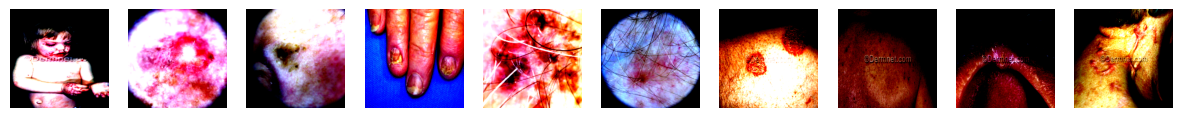

Class Labels Mapping: {1: '10. Warts Molluscum and other Viral Infections - 2103', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k', 0: '1. Eczema 1677', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k'}

Displaying first 10 samples from Testing Dataset:


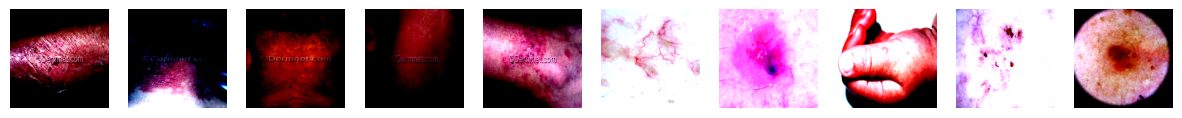

Class Labels Mapping: {1: '10. Warts Molluscum and other Viral Infections - 2103', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k', 0: '1. Eczema 1677', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k'}


In [5]:
import matplotlib.pyplot as plt

print("\nDisplaying first 10 samples from Training Dataset:")
plt.figure(figsize=(15, 5))

class_labels = {}

for i in range(10):
    image, label = train_dataset[i]  
    class_labels[label] = train_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off')

plt.show()
print("Class Labels Mapping:", class_labels)

print("\nDisplaying first 10 samples from Testing Dataset:")
plt.figure(figsize=(15, 5))

for i in range(10):
    image, label = test_dataset[i]
    class_labels[label] = test_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off') 

plt.show()
print("Class Labels Mapping:", class_labels)


In [6]:
# Load Pretrained EfficientNet Model
model = models.efficientnet_b0(pretrained=True)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train(model, criterion, optimizer):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_accuracy = correct / total
    train_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    train_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    train_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    wandb.log({
        "Training/Loss": train_loss / len(train_loader),
        "Training/Accuracy": train_accuracy,
        "Training/Precision": train_precision,
        "Training/Recall": train_recall,
        "Training/F1_Score": train_f1
    })

    return train_loss / len(train_loader), train_accuracy, train_precision, train_recall, train_f1


In [8]:

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    eval_accuracy = correct / total
    eval_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    eval_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    eval_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    wandb.log({
        "Evaluation/Accuracy": eval_accuracy,
        "Evaluation/Precision": eval_precision,
        "Evaluation/Recall": eval_recall,
        "Evaluation/F1_Score": eval_f1
    })

    return eval_accuracy, eval_precision, eval_recall, eval_f1

In [9]:
def train_model(model, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train(model, criterion, optimizer)
        eval_acc, eval_prec, eval_rec, eval_f1 = evaluate(model)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}, F1: {train_f1:.4f}")
        print(f"Eval  - Acc: {eval_acc:.4f}, Prec: {eval_prec:.4f}, Rec: {eval_rec:.4f}, F1: {eval_f1:.4f}")

    return model

model = train_model(model, criterion, optimizer, EPOCHS_NUM)


Epoch [1/50]
Train - Loss: 0.9198, Acc: 0.6366, Prec: 0.6347, Rec: 0.6366, F1: 0.6353
Eval  - Acc: 0.6946, Prec: 0.7134, Rec: 0.6946, F1: 0.6877
Epoch [2/50]
Train - Loss: 0.6549, Acc: 0.7528, Prec: 0.7525, Rec: 0.7528, F1: 0.7524
Eval  - Acc: 0.7747, Prec: 0.7801, Rec: 0.7747, F1: 0.7733
Epoch [3/50]
Train - Loss: 0.5016, Acc: 0.8137, Prec: 0.8137, Rec: 0.8137, F1: 0.8135
Eval  - Acc: 0.7728, Prec: 0.7782, Rec: 0.7728, F1: 0.7735
Epoch [4/50]
Train - Loss: 0.3982, Acc: 0.8515, Prec: 0.8518, Rec: 0.8515, F1: 0.8516
Eval  - Acc: 0.7742, Prec: 0.7853, Rec: 0.7742, F1: 0.7757
Epoch [5/50]
Train - Loss: 0.3144, Acc: 0.8891, Prec: 0.8891, Rec: 0.8891, F1: 0.8891
Eval  - Acc: 0.7993, Prec: 0.8012, Rec: 0.7993, F1: 0.7983
Epoch [6/50]
Train - Loss: 0.2553, Acc: 0.9071, Prec: 0.9071, Rec: 0.9071, F1: 0.9070
Eval  - Acc: 0.7933, Prec: 0.7981, Rec: 0.7933, F1: 0.7888
Epoch [7/50]
Train - Loss: 0.2077, Acc: 0.9252, Prec: 0.9253, Rec: 0.9252, F1: 0.9253
Eval  - Acc: 0.7877, Prec: 0.7923, Rec: 0.78

In [10]:
model.eval()
correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Final Accuracy on {len(test_dataset)} test images: {accuracy:.2f} %')

wandb.log({"final_test_accuracy": accuracy})


Final Accuracy on 2148 test images: 78.68 %


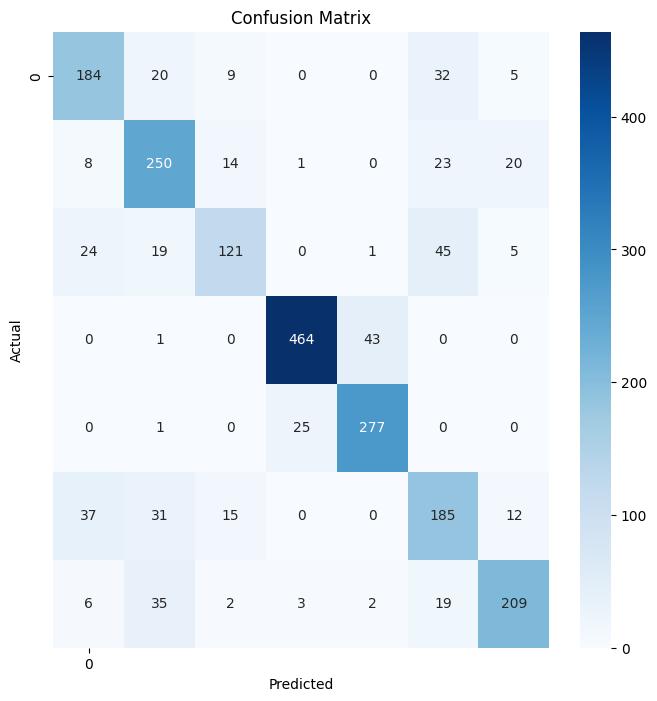

In [11]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Логування у wandb (якщо потрібно)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()

In [12]:
torch.save(model.state_dict(), "efficientnet_skin_disease_model.pth")
print("Model training complete and saved.")

Model training complete and saved.


In [13]:
wandb.finish()

Evaluation/Accuracy,▁▆▆▆█▇▇▇▆▇▇▇▆▆▇▆▇▇▇█▆▆▇█▇▆█▇▅▇▇▆▇█▇▇▇▇▆▇
Evaluation/F1_Score,▁▆▆▆█▇▇▇▇▇▇▇▆▆▇▆▇▇▇█▆▆▇██▆█▇▇▇▇▇▆▇█▇▇▇▆▇
Evaluation/Precision,▁▆▆▆█▇▇▇▇▇█▆▇▇█▇▇▇█▆▆▇██▇█▇▆▇▇▇▇▆▇█▇▇▆▇▇
Evaluation/Recall,▁▆▆▆█▇▇▆▇▇▇▆▆▇█▇▇▇█▅▆▇█▇▇█▇▅▇▇▇▇▆▇█▇▇▇▇▆
Training/Accuracy,▁▃▅▅▆▇▇▇▇▇▇▇████████████████████████████
Training/F1_Score,▁▃▅▅▆▇▇▇▇▇▇█████████████████████████████
Training/Loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training/Precision,▁▃▄▅▆▇▇▇▇▇▇▇▇▇▇█▇▇██▇███████▇███████████
Training/Recall,▁▃▅▅▆▇▇▇▇▇▇█████████████████████████████
final_test_accuracy,▁
Evaluation/Accuracy,0.78678
